# 학습내용

1. GGUF 모델 변환의 필요성
2. GGUF 모델 성능 테스트
3. GUFF 모델 변환 하기
4. Benchmark Tool로 성능 테스트
5. GGUF 포맷의 한계점
6. GGUF 모델 허깅페이스에 배포하기

# 1. GGUF 모델 변환의 필요성
- 모델 변환을 왜 해야하는지에 대해서 이해해 봅시다.

### llama.cpp 라이브러리 소개

- 모델변환이 왜 필요한지 살펴보기 전, llama.cpp 라이브러리부터 알아봅시다.


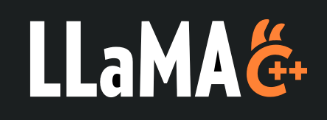

- llama.cpp는 C언어와 C++로 만들어진 **고성능 추론 Library**입니다!






- 반드시 써야하는 건 아닙니다!
  - 파인튜닝하고, 추론 테스트 할때는 PyTorch로 하면 충분합니다!
  - 연구할 때, 토이 프로젝트를 제작할때는 PyTorch, Transformers Library면 충분합니다!

- 하지만, **추론 서비스를 운영할때는 고성능 llama.cpp 라이브러리를 사용합니다,**
  - 허깅페이스의 Transformer로 추론하는 것보다 더 빠릅니다!
  - Unsloth로 추론하는 것 보다 더 빠릅니다!
  - 메모리를 더 적게 사용하고, 추론 속도가 빨라서 사용합니다!
    - AI 서비스를 운영할때는 추론속도가 빨라야 GPU 부담이 줄어듭니다.

### 모델 변환의 필요성 이해

- llama.cpp를 아주 간단히 소개드렸고, 이제 **왜 모델 변환이 필요한지 천천히 살펴봅시다.**

- 이전 수업에서 허깅페이스에 업로드된 모델을 다운로드 받아서 로드 했습니다.
  - .safetensors 라는 파일을 다운로드 받았었죠.
  - PyTorch가 사용하는 확장자입니다.

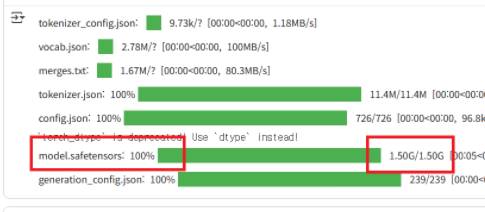

- 이렇게 다운로드 받고, 모델을 로드한 뒤 이런 일들을 해왔습니다.
  - 파인튜닝 or 추론을 해왔었죠.

- 파인튜닝으로 나만의 모델을 만들었습니다!
- 이제 세상 사람들이 내 모델을 사용할 수 있게끔, 챗봇 서비스를 만들 겁니다.

- 챗봇 서비스를 만들었는데, 답변 속도가 너무 느립니다.
  - 사용자들이 너무 느리다고 불만을 가집니다. ㅠㅠ
- GPU를 더 구매해도 되겠지만 너무 비싸요.
  - A100 GPU, 80GB 는 1,500만원이예요


- 방법을 찾았습니다!
  - 추론할때는 허깅페이스의 Transformer 라이브러리 대신 고성능 추론 Library를 사용하면 됩니다.
  - GPU를 추가 구매하지 않아도, 속도를 올릴 수 있습니다!

- 앗!!! llama.cpp 라이브러리는 PyTorch용 모델을 (.safetensor)를 지원하지 않습니다.
  - GGUF포맷 파일인 '.gguf' 파일로된 모델만 지원합니다. ㅠㅠ

- 그럼 내가 만든 모델을 llama.cpp 라이브러리에 쓸 수 있도록 GUFF로 변환해야합니다.

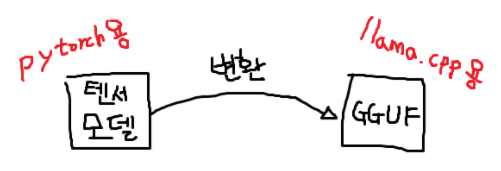

- 여기까지 모델을 변환해야하는 이유였습니다.

### GGUF에 대해서

- llama.cpp에서는 GGUF 포맷만을 지원합니다
  - 이 Library는 PyTorch 모델을 지원하지 않습니다.
  - 고성능 추론을 위해 GGUF 포맷의 모델로 변환을 할 수 밖에 없습니다.

- GGUF 라는 이름은 개발자의 이름을 따서 만들었습니다.
  - llama.cpp 라이브러리 개발자 이름은 Georgi Gerganov (조지 거가노브, 줄여서 GG) 입니다.
  - 그리고 GGUF의 약어는 Georgi Gerganov Unified Format 이죠.

- 이 GGUF 포맷을 따르는 파일은 .gguf 확장자를 갖습니다.
- 이 파일에는 다음과 같은 정보가 다~ 들어있습니다.
  - 텐서 파일 (Weight값)
  - Vocab
  - Model 메타정보
  - (양자화를 했다면, 양자화 정보)
  - 등등

- 이 파일 하나만 있으면 tokenizer, config 등 이런 파일들이 필요없어요.

### 허깅페이스에서 GGUF 구경하기

- 아래 사이트에 접속하여 Quantizations 버튼을 눌러봅시다.
  - https://huggingface.co/Qwen/Qwen3-0.6B
  - 아래 링크에서 양자화된 모델을 확인할 수 있습니다.

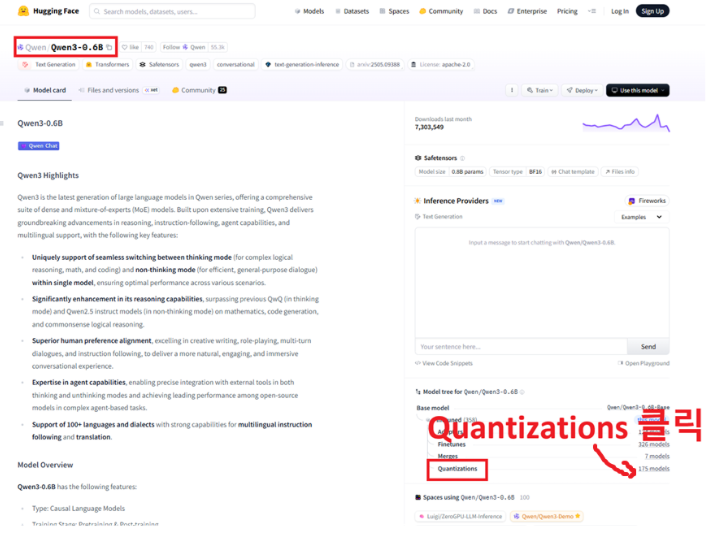

- 친숙한 unsloth가 보이네요.
  - unsloth의 GGUF 모델을 클릭해봅시다.

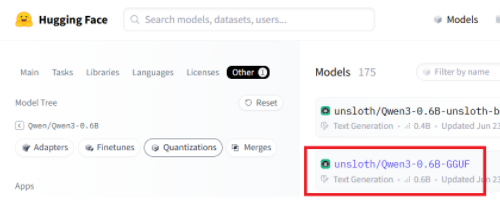

- 이후 Files 탭을 누르면 gguf 파일들을 확인할 수 있습니다.

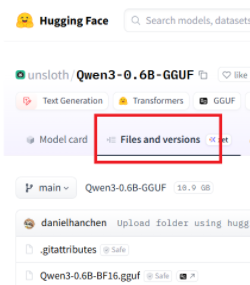

- PyTorch 모델은 .safetensors 파일로 되어있었지만,<br/>
  GGUF로 변환된 모델은 .gguf 파일로 되어있음을 확인할 수 있습니다.

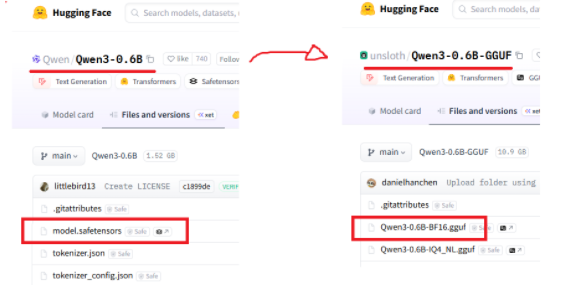

- 파일이 엄청 많습니다.

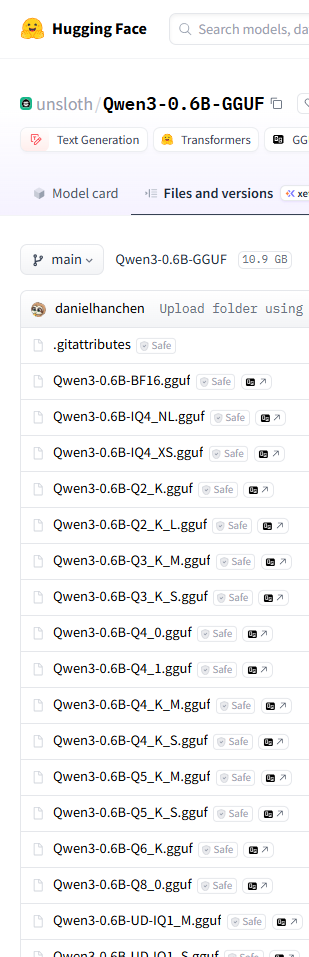


  - 이건 종류별로 하나씩 다 만든겁니다.
    - 아메리카노, 라떼, 프라페치노... 각각 동작되는 모델입니다.
    - **.gguf 파일 하나만 있으면 추론이 잘 됩니다.**
  - BF16 : 양자화 없는 원본
  - IQ : 더 정밀하고 손실이 적은 4bit 양자화
  - Q2, Q3, Q4, Q6.. = 양자화 bit 수
  - 그 뒤에 옵션은 양자화 세부 옵션들 (K_L, K_M, K_S)
- 이중에서 뭘 쓸까요?
  - llama.cpp 라이브러리가 가장 권장 권장하는 옵션은 **Q4_K_M** 입니다. 이걸 사용하면 됩니다.
  
  

# 2. GGUF 모델 성능 테스트
- GGUF 변환 후, 추론 속도가 정말 좋아지는지 확인해봅니다.


### GGUF 파일 추론 테스트
- llama.cpp 라이브러리를 사용하여 추론을 해봅시다.
- C++ Library의 Python 래퍼 가 있습니다.
  - llama-cpp-python 입니다.
    - 아래 설치 명령어는 GPU 옵션이 켜있는 패키지를 다운 받는 명령어입니다.
    - CUDA 12.1 버전은 CUDA 12.4 버전과 호환이 잘 됩니다.

In [ ]:
%%capture
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu121
!pip install huggingface_hub

- 이후 GGUF 모델을 다운로드합니다.

In [ ]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="unsloth/Qwen3-0.6B-GGUF",
    filename="Qwen3-0.6B-BF16.gguf" # 양자화 안된 gguf
    #filename="Qwen3-0.6B-Q4_K_M.gguf" # 4bit 양자화 된 gguf
)
print("모델 다운로드 완료:", model_path)

- 모델을 로드합니다.

In [ ]:
from llama_cpp import Llama

llm = Llama(
    model_path=model_path, # 다운로드한 GGUF 파일 경로
    n_gpu_layers=-1, # -1 : gpu에 모든 Layer 로드
    verbose=False, # 추론시 로그 출력 OFF
)


- 추론 시작!

In [ ]:
import time, re

def qwen_prompt(user_text, system_text):
    return f"<|im_start|>system\n{system_text}<|im_end|>\n<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n"

user_text = "좋아하는 음식과 특징을 말해줘"
print(f"사람 : {user_text}")

system_text = "짧게 단답형으로 대답해"
prompt = qwen_prompt(user_text, system_text)

def invoke():
    start = time.time() # 시간측정 시작
    response = llm(prompt, max_tokens=512, temperature=0.7)
    elapsed = time.time() - start # 시간측정 끝

    # 결과 저장
    result = response["choices"][0]["text"].split("</think>")[-1].strip()

    print(f"AI : {result}")
    print(f"추론시간 : ⏱ {elapsed:.2f}s")

    num_tokens = len(result.replace(" ", ""))
    return (elapsed, num_tokens)

acc_elapsed = 0.0
acc_tokens = 0
limit_tokens = 1000
while True:
  elapsed, num_tokens = invoke()
  acc_elapsed = acc_elapsed + elapsed
  acc_tokens = acc_tokens + num_tokens

  print(f"누적 토큰 수: {acc_tokens} / {limit_tokens}")
  print()

  # 생성된 예상 토큰수가 1000개 넘어가면 종료
  if acc_tokens > limit_tokens :
    break

tps = acc_tokens / acc_elapsed

print(f"🧮 예상 토큰 수: {acc_tokens}")
print(f"⚡ 초당 처리 속도: {tps:.2f} tokens/sec")

### PyTorch 모델 추론 vs GGUF 모델 추론 속도 비교

- .gguf 모델은 배포용으로 사용된다고 배웠습니다.
  - C++ 기반 추론 Library인 llama.cpp 를 쓰기 위함입니다.

- 얼마나 성능차이가 나는지 확인해봅시다!
  - GGUF 성능이 더 빠른것을 확인할 수 있습니다.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
model_name = "Qwen/Qwen3-0.6B"

# 모델 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16, #BF16
    device_map="auto"
)

In [ ]:
import time, re
user_text = "좋아하는 음식과 특징을 말해줘"
print(f"사람 : {user_text}")

system_text = "짧게 단답형으로 대답해"

messages = [
    {"role": "system", "content": system_text},
    {"role": "user", "content": user_text}
]

# Qwen 템플릿으로 변경
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False # Switches between thinking and non-thinking modes. Default is True.
)

# 토크나이저
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)


def invoke():
    start = time.time() # 시간측정 시작
    generated_ids = model.generate(**model_inputs, max_new_tokens=512)
    elapsed = time.time() - start # 시간측정 끝

    # 결과 저장
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()
    result = tokenizer.decode(output_ids[0:], skip_special_tokens=True).strip("\n")

    print(f"AI : {result}")
    print(f"추론시간 : ⏱ {elapsed:.2f}s")

    num_tokens = len(result.replace(" ", ""))
    return (elapsed, num_tokens)

acc_elapsed = 0.0
acc_tokens = 0
limit_tokens = 1000
while True:
  elapsed, num_tokens = invoke()
  acc_elapsed = acc_elapsed + elapsed
  acc_tokens = acc_tokens + num_tokens

  print(f"누적 토큰 수: {acc_tokens} / {limit_tokens}")
  print()

  # 생성된 예상 토큰수가 1000개 넘어가면 종료
  if acc_tokens > limit_tokens :
    break

tps = acc_tokens / acc_elapsed

print(f"🧮 예상 토큰 수: {acc_tokens}")
print(f"⚡ 초당 처리 속도: {tps:.2f} tokens/sec")

### 실험 결과

- GGUF가 확실히 빠르게 토큰을 생성해냅니다.
- 추론 안정성도 차이가 있었습니다.
  - GGUF는 한번에 결과가 잘 나오는데, PyTorch는 4번중 1번 실행시 무한루프에 빠지곤 했습니다.
- 생성된 문장의 품질은 비교하지 못했습니다.
  - 이는 LLM as a judge 를 통해 평가할 수 있습니다.
- 역시 배포는 GGUF로 해야되겠습니다.

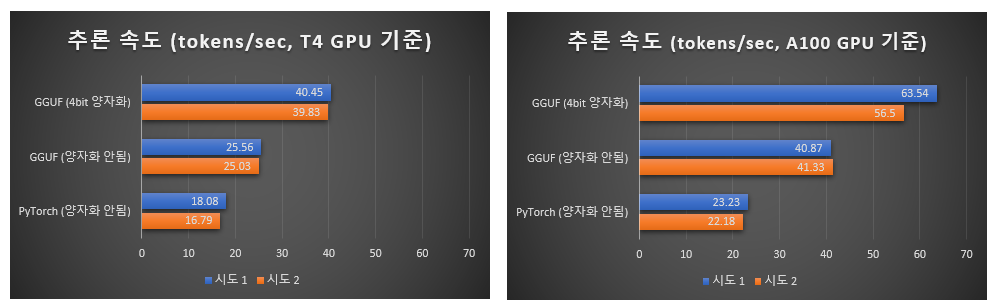

# 3. GUFF 모델 변환하기


### 변환할 모델 준비

- 이번 챕터에서는 PyTorch 모델을 직접 GGUF로 변환 후 추론까지 해보겠습니다.
- 먼저 모델을 로드 후, 파일로 저장하겠습니다.

In [ ]:
# 모델 저장
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-0.6B"

# 모델 다운로드 & 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


# 이후 파인튜닝을 다 했다고 가정합니다.
# 파인튜닝 코드 시작
# ...~
# 파인튜닝 코드 끝


# 파인튜닝 완료된 모델 저장 (5분 소요)
print('모델 저장중...')
save_path = "./my_trained_model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("모델 저장 완료:", save_path)


- 저장이 잘 된것을 확인할 수 있습니다.

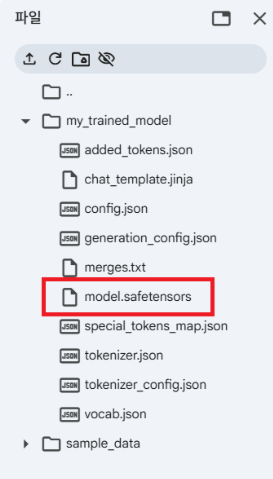

### GGUF 포맷으로 변환

- 이제 .safetensors --> GGUF로 변환을 해야하는데 두 가지 방법이 있습니다.

- 방법1 : llama.cpp 공식 가이드
  1. `git clone https://github.com/ggerganov/llama.cpp` 으로 Clone 받고
  2. convert_hf_to_gguf.py로 GGUF 변환 (BF16)을 하고
  3. 빌드하고 (cmake)
  4. llama-quantize 툴로 4bit 양자화를 한다.

<br/>

- **방법2 : Unsloth 함수 호출**
  1. save_pretrained_gguf() 함수를 호출한다.
      - 내부적으로 위 동작을 수행합니다.
  2. 끝!

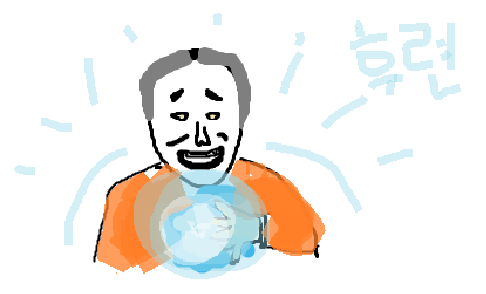

- unsloth 를 설치합시다.

In [ ]:
!pip install unsloth

- [Trouble Shooting] 아래는 버전 충돌로 인한 해결책입니다.

In [ ]:
!pip uninstall -y pyarrow
!pip install pyarrow==17.0.0

- 변환합니다!
  - 아래 코드를 실행하면, 16분 정도 걸린다고 로그 메세지가 나옵니다.

In [ ]:
from unsloth import FastLanguageModel

# 기존 저장된 모델 경로
model_path = "./my_trained_model"

# GGUF 변환 (오래걸림)
model, tokenizer = FastLanguageModel.from_pretrained(model_path, dtype = None)

# 양자화 후 저장
model.save_pretrained_gguf(
    model_path,
    tokenizer = tokenizer,
    quantization_method = "q4_k_m",
)

print('변환 완료!')

- 아래 파일이 생성 되었으면 성공입니다.

image.png

### 생성한 .gguf파일 추론 테스트

- 생성된 파일을 추론테스트 해봅니다.

In [ ]:
from llama_cpp import Llama

# 로컬 파일을 불러옵니다.
model_path = "./my_trained_model.Q4_K_M.gguf"

llm = Llama(
    model_path=model_path, # 다운로드한 GGUF 파일 경로
    n_gpu_layers=-1, # -1 : gpu에 모든 Layer 로드
    verbose=False, # 추론시 로그 출력 OFF
)

In [ ]:
def qwen_prompt(user_text, system_text):
    return f"<|im_start|>system\n{system_text}<|im_end|>\n<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n"

user_text = "좋아하는 음식과 특징을 말해줘"
print(f"사람 : {user_text}")

system_text = "짧게 단답형으로 대답해"
prompt = qwen_prompt(user_text, system_text)

response = llm(prompt, max_tokens=512, temperature=0.7)

# 결과 저장
result = response["choices"][0]["text"].split("</think>")[-1].strip()

print(f"AI : {result}")

- 여기까지 모델 변환을 해보았습니다.
  - 이제 LLM 모델을 파인튜닝을 하신 후, GGUF로 변환 후 추론까지 가능해졌습니다.

# 4. Benchmark Tool로 성능 테스트

### 벤치마크 도구 준비

- 3번 실습에서 unsloth로 GGUF를 수행하면 llama.cpp가 Clone & Build가 됩니다.
- llama.cpp 폴더 안에는 추론 속도를 테스트 할 수 있는 도구가 포함되어있습니다.

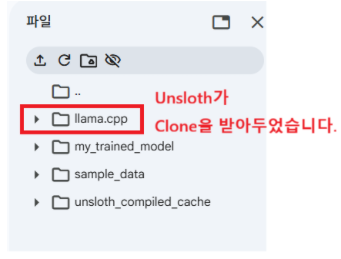

- 벤치마크 툴을 실행을 위해 빌드합니다.
  - 10분 걸립니다.
    - 멈춰있는 것 같지만, 빌드 중입니다.

In [ ]:
%cd llama.cpp
!cmake -B build -DGGML_CUDA=on -DLLAMA_BUILD_TOOLS=ON

In [ ]:
!cmake --build build --target llama-bench -j

### 벤치마크 수행

- 벤치마크 툴을 실행해봅니다.
  - pp512
    - 한번에 512개 토큰 단위로 모델에 입력합니다
    - 이때, 1초에 **입력(인코딩)** 처리 할수 있는 있는 토큰 수를 나타냅니다.
  - tg128
    - 한번에 128개 토큰 단위로 생성합니다.
    - 이때, 1초에 **생성(디코딩)** 할 수 있는 토큰 수를 나타냅니다.

In [ ]:
%cd /content/
!./llama.cpp/build/bin/llama-bench -m ./my_trained_model.Q4_K_M.gguf -p 512 -n 128

### 벤치마크 결과 분석

- 만약 출력결과가 아래와 같으면, 이렇게 해석합니다.
  - 인코딩 속도 : 초당 16,369개 토큰
  - 디코딩 속도 : 초당 343개 토큰

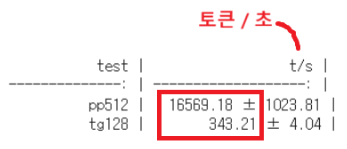

- 이번엔 모델을 더 추가해서 모델별 성능비교를 해봅시다.

In [ ]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="unsloth/Qwen3-0.6B-GGUF",
    filename="Qwen3-0.6B-BF16.gguf", # 양자화 안된 gguf
    local_dir="./"
)

print("모델 다운로드 완료")

- 다운로드 받은 모델 성능을 측정하고, 비교해봅시다.
  - 이번엔 양자화가 안된 모델이므로, 성능이 더 낮을 것입니다.

In [ ]:
%cd /content/
!./llama.cpp/build/bin/llama-bench -m ./Qwen3-0.6B-BF16.gguf -p 512 -n 128

- 이렇게 양자화를 함으로써, 정확한 데이터로 추론 속도를 비교할 수 있었습니다.

- 모델별 성능 비교도 가능하지만, HW 성능 측정도 가능합니다.
  - 한 모델을 기준으로, 여러 장치들을 바꿔가면서 성능측정 할 수 있습니다.
  - 아래 링크를 보시면, Llama 2 7B 기준의 Score 보드입니다.
    - https://github.com/ggml-org/llama.cpp/discussions/15013
      - RTX 5090 GPU가 A100 GPU보다 경량모델의 추론속도가 빠르군요!


- 여기까지 모델의 추론 속도를 정확히 측정하는 방법을 학습했습니다.

# 5. GGUF 포맷의 한계점

### GGUF 포맷의 한계점

- GGUF은 추론 전용 포맷입니다!
  - GGUF로 변환된 모델은 LoRA 등 파인튜닝이 되지 않습니다.
- GGUF는 Transformer 계열 LLM 전용입니다!
  - CNN 기반 모델 사용 불가능합니다.
  - 멀티모달 LLM은 제한적으로 사용 가능합니다.
  - ViT와 같은 이미지 Transformer 모델도 제한적입니다.

<br/>

- GGUF로 양자화가 안되는 모델의 대안은 무엇이 있을까요!?
  - 바로 **TFLite** 입니다.
    - TensorFlow의 Lite 버전 입니다.
    - Google이 만든 경량화된 모델을 위한 프레임워크입니다.
      - PyTorch로 안되니, Tensorflow로 해야죠 ㅎㅎ

### TFLite 의 활용처
  - 임베디드 환경에서 가장 많이 쓰입니다.
    - 임베디드 장치는 tflite만 지원하는 경우가 많습니다.
  - 모바일 환경에서도 쓰입니다.    
    - TensorFlow Lite SDK 를 활용한 iOS / Android App을 만들 수 있습니다.
  - 서버 환경에서도 쓰입니다.
    - llama.cpp를 사용하지 못하는 모델에 사용됩니다.
    - CNN 기반 모델, 멀티모달 Transformer 등 지원합니다.
    - 정확히 사용하고자 하는 모델별로 지원 여부를 확인 후 사용해야합니다!
  - EASY 교안에서는 TFLite를 다루지 않습니다~.

# 6. 모델 배포

### 모델을 허깅페이스의 Repository에 Push하기


- 지금까지 양자화를 하여 배포할 준비를 끝냈으니, 이번 챕터에서는 모델을 배포해보겠습니다.
- 허깅페이스에 접속하여 Model Repository를 생성해주세요.

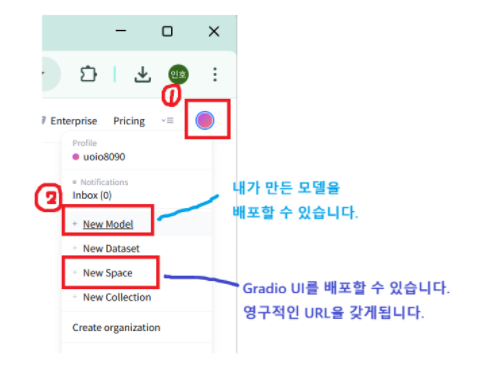

- Public으로 생성합니다.
  - 모델이름은 자유롭게 정합니다.

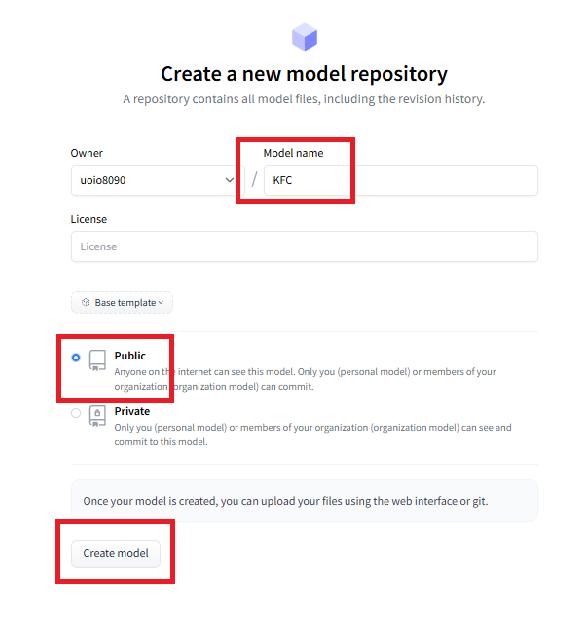

- Model Card에 Push 하는 명령어가 나와있습니다.

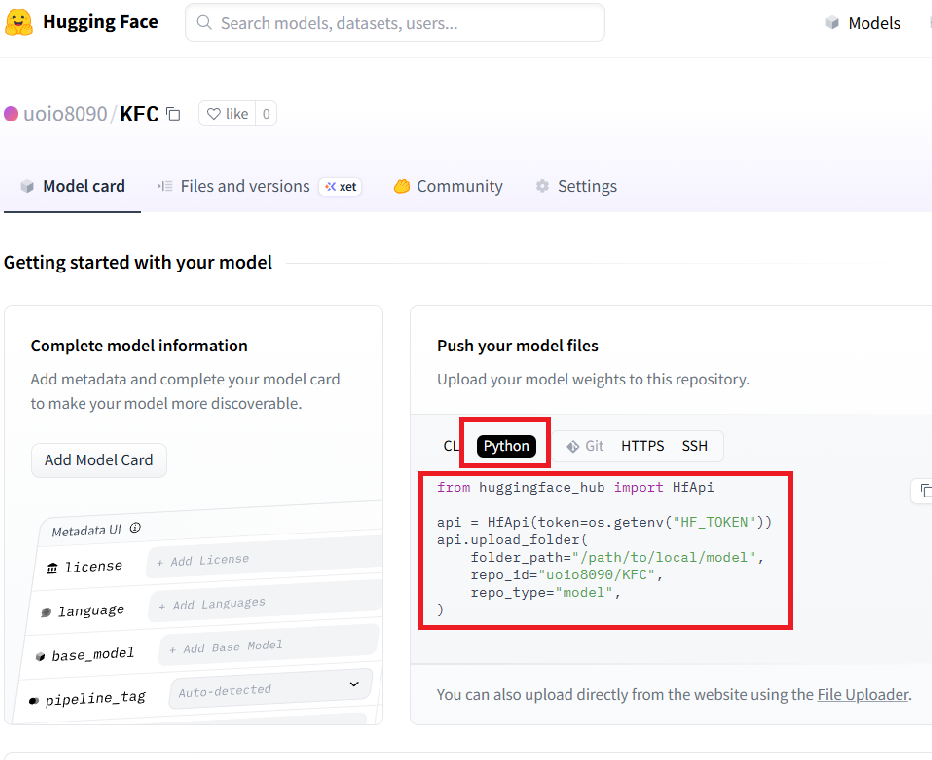

- 허깅페이스 키가 필요합니다. Write 권한으로 생성 해주세요.

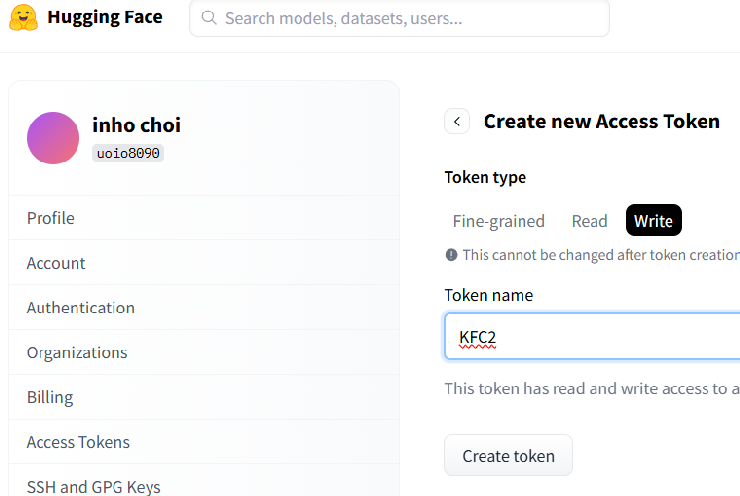

- 아래와 같이 등록해두었습니다.

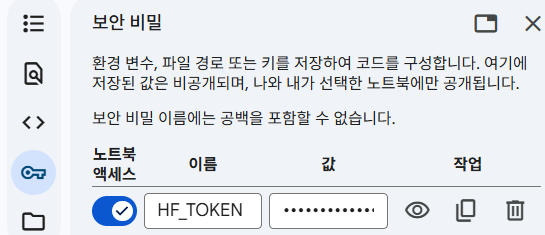

- 아래 코드를 수정하여 Push를 합시다.
  - 본인의 Repository로 수정하여 Push 합니다.

In [ ]:
from huggingface_hub import HfApi
import os

from google.colab import userdata
api = HfApi(token=userdata.get('HF_TOKEN'))

api.upload_file(
    path_or_fileobj="./my_trained_model.Q4_K_M.gguf",  # 로컬 파일 경로
    path_in_repo="my_trained_model.Q4_K_M.gguf",       # HF Hub에서 보일 파일 이름
    repo_id="uoio8090/KFC",                            # 본인 Repo (예: username/repo)
    repo_type="model",                                 # 모델 repo
)

- Push가 완료 되었습니다.

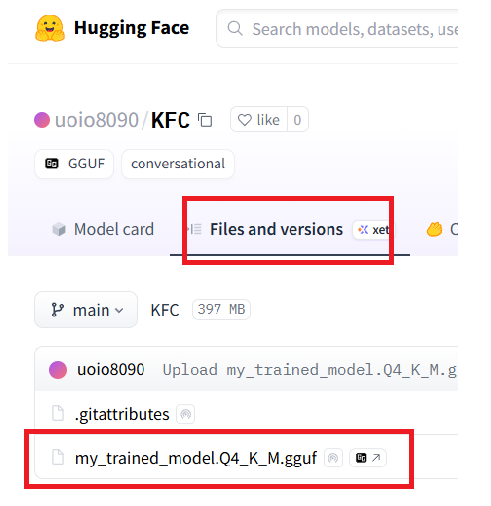

- 다음 실습을 위해 Model Repository 이름을 메모해주세요.

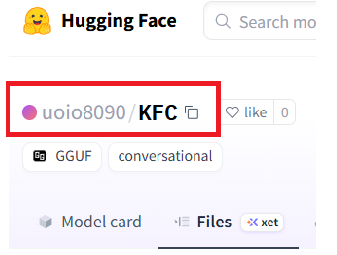

### Push한 모델 동작 테스트

- 아래 코드가 잘되는지 확인합니다.
  - 본인의 Repo 명과 GGUF 파일명으로 바꿔주세요


In [ ]:
import gradio as gr
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

# ========================================
# 모델 다운로드
# ========================================
REPO_ID = "uoio8090/KFC"                     # Hugging Face Repo
MODEL_FILE = "my_trained_model.Q4_K_M.gguf"  # GGUF 파일명

model_path = hf_hub_download(repo_id=REPO_ID, filename=MODEL_FILE)

# ========================================
# 모델 로드
# ========================================
llm = Llama(
    model_path=model_path, # 다운로드한 GGUF 파일 경로
    n_gpu_layers=-1, # -1 : gpu에 모든 Layer 로드
    verbose=False, # 추론시 로그 출력 OFF
)

# ========================================
# 추론 함수 정의
# ========================================
def qwen_prompt(user_text, system_text):
    return f"<|im_start|>system\n{system_text}<|im_end|>\n<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n"

def invoke(prompt):
    response = llm(prompt, max_tokens=512, temperature=0.7)
    result = response["choices"][0]["text"].split("</think>")[-1].strip()
    return result

def chat(message, history):
    system_text = "친절하게 대답해"
    prompt = qwen_prompt(message, system_text)
    answer = invoke(prompt)

    history = history + [
        {"role": "user", "content": message},
        {"role": "assistant", "content": answer}
    ]
    return "", history

# ========================================
# Gradio Blocks 기반 UI
# ========================================
with gr.Blocks(title="LangChain Agent Chat") as demo:
    gr.Markdown("## 🤖 LangChain Agent Chat\nLangChain Agent가 도구를 활용해 답변합니다.")

    chatbot = gr.Chatbot(
        height=300,
        label="대화창",
        type="messages"
    )

    msg = gr.Textbox(
        label="💬 질문을 입력하세요",
        placeholder="예: 오늘 서울 날씨 어때?",
    )

    # 엔터 누르면 chat 함수 호출
    msg.submit(chat, inputs=[msg, chatbot], outputs=[msg, chatbot])

demo.launch(share=True)

# 7. 미션

다음 미션을 수행하고 평생 링크 URL을 MM 으로 남겨주세요!
  1. Qwen3-0.6B 모델을 파인튜닝 (제주도 사투리 파인튜닝)
  2. 4 bit 양자화 (GGUF)
  3. 허깅페이스에 모델 Push하기
  4. Gradio로 나만의 AI Service 제작!
  5. 성공하신 분은 URL을 MM으로 제출해주세요~

In [2]:
# 새 가상환경 권장 (선택)
# python -m venv .venv && source .venv/bin/activate  # (Windows: .venv\Scripts\activate)

# 필수 라이브러리 설치
pip install -U "transformers>=4.44.0" datasets accelerate peft bitsandbytes trl
pip install -U sentencepiece


SyntaxError: invalid syntax (5518791.py, line 5)